In [10]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import ttest_ind
from natsort import natsorted
from sklearn.decomposition import PCA
import nibabel.freesurfer.io as fsio
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
import glob
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os
from scipy.stats import linregress
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind
from sklearn.metrics import pairwise_distances
import nibabel as nib
import sys
import seaborn as sns
from nibabel import cifti2
from scipy.spatial import procrustes
from scipy.stats import ttest_ind
np.random.seed(42)

In [11]:
motions = glob.glob('../Dataset/deaf/fmriprep/sub-*/func/sub-*_task-resting_desc-confounds_timeseries.tsv')
fd = []
ids = []
for m in motions:
    df = pd.read_csv(m, sep='\t')
    fd.append(df['framewise_displacement'].mean())
    ids.append(m.split('/')[-3])

In [12]:
df_motion = pd.DataFrame([ids, fd]).T

In [13]:
import nibabel as nib
labels, ctab, names = nib.freesurfer.read_annot('../Dataset/template/lh.Schaefer2018_400Parcels_17Networks_order.annot')
roi_names = [name.decode('utf-8') for name in names]
left = roi_names[1:]
labels, ctab, names = nib.freesurfer.read_annot('../Dataset/template/rh.Schaefer2018_400Parcels_17Networks_order.annot')
roi_names = [name.decode('utf-8') for name in names]
right = roi_names[1:]
labels = []
for x in left + right:
    network = x.split('_')[2]
    if 'Vis' in network:
        labels.append(1)
    elif 'SomMot' in network:
        labels.append(2)
    elif 'DorsAttn' in network:
        labels.append(3)   
    elif 'SalVentAttn' in network:
        labels.append(4)
    elif 'Limbic' in network:
        labels.append(5) 
    elif 'Cont' in network:
        labels.append(6)
    elif 'Default' in network:
        labels.append(7)
    elif 'TempPar' in network:
        labels.append(2)
    else:
        print(network)
region_label = labels

In [14]:
import numpy as np

mask = np.zeros(400, dtype=np.uint8)

with open("../Derivatives/auditory_Julich_schaefer_overlaps.txt") as f:
    for line in f:
        _, vals = line.split(":")
        idx = np.fromstring(vals, sep=" ", dtype=int)
        mask[(idx-1)] = 1

mask_5 = np.zeros(400, dtype=np.uint8)

with open("../Derivatives/auditory_Julich_schaefer_overlaps_5percent.txt") as f:
    for line in f:
        _, vals = line.split(":")
        idx = np.fromstring(vals, sep=" ", dtype=int)
        mask_5[(idx-1)] = 1

In [15]:
df = pd.DataFrame([mask, mask_5, region_label], index=['mask', 'mask_5', 'region_label']).T
df['overlap'] = ((df['mask'] == 1) & (df['region_label'] == 2)).astype(int)
df['overlap_5'] = ((df['mask_5'] == 1) & (df['region_label'] == 2)).astype(int)
df.loc[(df['mask'] == 1) & (df['region_label'] == 2), 'region_label'] = 8

In [16]:
region_label = df['region_label'].values

In [17]:
blind_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_rh_Schaefer2originalWang.npy')
blind_MMP_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_lh_Schaefer2originalWang.npy')
control_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_rh_Schaefer2originalWang.npy')
control_MMP_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_lh_Schaefer2originalWang.npy')
deaf_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/deafsource_deaftarget_individual_fingerprint_fc_rh_Schaefer2Julich.npy')
deaf_MMP_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/deafsource_deaftarget_individual_fingerprint_fc_lh_Schaefer2Julich.npy')
deaf_control_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/deaf_controlsource_deaf_controltarget_individual_fingerprint_fc_rh_Schaefer2Julich.npy')
deaf_control_MMP_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/deaf_controlsource_deaf_controltarget_individual_fingerprint_fc_lh_Schaefer2Julich.npy')

In [18]:
network_names = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default', 'Auditory']
labels = [f"{i}_{j}" for i in network_names for j in network_names]

# Blind

In [19]:
blind_V1 = []
for i in np.arange(blind_MMP_rh.shape[0]):
    corr_matrix = blind_MMP_rh[i].T
    z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(z_matrix)
    corr_df.index = region_label[200:]
    V1_cols = [0,1] 
    visual_df = corr_df.iloc[:, V1_cols]
    avg_visual = visual_df.mean(axis=1).values
    blind_V1.append(avg_visual)

In [20]:
control_V1 = []
for i in np.arange(control_MMP_rh.shape[0]):
    corr_matrix = control_MMP_rh[i].T
    z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(z_matrix)
    corr_df.index = region_label[200:]
    visual_df = corr_df.iloc[:, V1_cols]
    avg_visual = visual_df.mean(axis=1).values
    control_V1.append(avg_visual)

In [21]:
cb = pd.read_csv('../Dataset/fingerprint_FC_dataset/Italy_blind_subjects', header=None)[0].values
sc = pd.read_csv('../Dataset/fingerprint_FC_dataset/Italy_control_subjects', header=None)[0].values
pi = pd.read_csv('../Dataset/fingerprint_FC_dataset/Italy_pilot_subjects', header=None)[0].values

In [22]:
df_V1_rh = pd.concat([pd.DataFrame(blind_V1), pd.DataFrame(control_V1)]).reset_index(drop=True)
df_V1_rh.columns = region_label[200:]
#df_V1_rh['subject'] = list(cb) + list(sc)
#df_V1_rh['group'] = list(np.repeat('blind', len(list(cb)))) +  list(np.repeat('control', len(list(sc)))) 
#df_V1_rh['hemi'] = 'rh'

In [24]:
wanglabel = pd.read_csv('../Dataset/template/Wang/ROIfiles_Labeling.txt', sep='\t')
wanglabel = [x.split('- ')[1] for x in wanglabel.index.values]

In [25]:
blind_V1 = []
for i in np.arange(blind_MMP_lh.shape[0]):
    corr_matrix = blind_MMP_lh[i].T
    z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(z_matrix)
    corr_df.index = region_label[:200]
    V1_cols = [idx for idx, label in enumerate(wanglabel) if 'V1' in label] # not in ['IPS0','IPS1','IPS2','IPS3','IPS4', 'IPS5', 'SPL1', 'FEF']] #[0,1] 
    visual_df = corr_df.iloc[:, V1_cols]
    avg_visual = visual_df.mean(axis=1).values
    blind_V1.append(avg_visual)

In [26]:
control_V1 = []
for i in np.arange(control_MMP_lh.shape[0]):
    corr_matrix = control_MMP_lh[i].T
    z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(z_matrix)
    corr_df.index = region_label[:200]
    visual_df = corr_df.iloc[:, V1_cols]
    avg_visual = visual_df.mean(axis=1).values
    control_V1.append(avg_visual)

In [27]:
df_V1_lh = pd.concat([pd.DataFrame(blind_V1), pd.DataFrame(control_V1)]).reset_index(drop=True)
df_V1_lh.columns = region_label[200:]
#df_V1_lh['subject'] = list(cb) + list(sc)
#df_V1_lh['group'] = list(np.repeat('blind', len(list(cb)))) +  list(np.repeat('control', len(list(sc)))) 
#df_V1_lh['hemi'] = 'lh'

In [28]:
#df_V1_merge = pd.concat([df_V1_lh, df_V1_rh])#
#df_V1_feature = pd.concat([df_V1_merge.iloc[:, :-3].T.groupby(df_V1_merge.columns[:-3]).mean().T, df_V1_merge.iloc[:, -3:]], axis=1)
#df_V1_feature.columns = ['V1_'+x for x in network_names] + ['subject', 'group', 'hemi']
#df_V1_feature.to_csv('../derivatives/blind_V1A1.csv', index=False)

In [29]:
df_V1 = (df_V1_rh + df_V1_lh)/2
df_V1['group'] = list(np.repeat('blind', blind_MMP_lh.shape[0])) +  list(np.repeat('control', control_MMP_lh.shape[0])) 

In [30]:
blind_t_V1 = []
blind_p_V1 = []
for i in np.arange(200):
    t, p = ttest_ind(df_V1[df_V1.group=='blind'].iloc[:, i].values,df_V1[df_V1.group=='control'].iloc[:, i].values,nan_policy='omit')
    blind_t_V1.append(t)
    blind_p_V1.append(p)

In [31]:
features = df_V1.iloc[:, :-1]
group = df_V1['group']
df_V1_network = features.T.groupby(features.columns).mean().T
#df_V1_network = df_V1_network.div(features.mean(axis=1), axis=0)
df_V1_network.columns = network_names 
df_V1_network['group'] = group

Visual 1.168864378702108 0.2510921934168094
SomMot -8.953399889448017 3.153023401764251e-10
DorsAttn -2.2199486072065002 0.03362944052916322
SalVentAttn -1.3776655283967771 0.1778659500382115
Limbic 3.6987236041820886 0.0008097765376655857
Cont 6.770346651707062 1.1906976637299166e-07
Default -0.16618842016451768 0.8690542775132277
Auditory -6.166464868753834 6.70961955945188e-07


/tmp/ipykernel_1614600/4187024217.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(network_order, rotation=30)


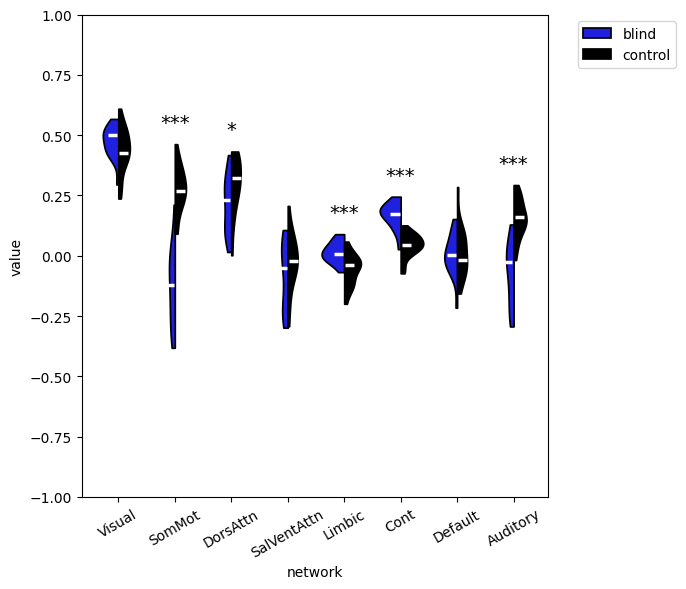

In [32]:
for region in [df_V1_network]:

    # -------------------------
    # Melt to long format
    # -------------------------
    df_long = region.melt(
        id_vars=['group'],
        var_name='network',
        value_name='value'
    )

    # Ensure stable order
    network_order = df_long['network'].unique()

    plt.figure(figsize=(7, 6))

    ax = sns.violinplot(
        x='network',
        y='value',
        hue='group',
        data=df_long,
        order=network_order,
        split=True,
        inner=None,
        cut=0,
        palette={'blind': 'blue', 'control': 'black'}
    )

    # -------------------------
    # Median computation
    # -------------------------
    medians = (
        df_long.groupby(['network', 'group'])['value']
        .median()
        .reset_index()
    )

    offset = 0.18

    for i, net in enumerate(network_order):
        for group, sign in zip(['blind', 'control'], [-1, 1]):

            val = medians.loc[
                (medians['network'] == net) &
                (medians['group'] == group),
                'value'
            ].values

            if len(val) == 0:
                continue

            ax.hlines(
                y=val[0],
                xmin=i + sign * 0.02,
                xmax=i + sign * offset,
                color='white',
                linewidth=2.5,
                zorder=10
            )

    # -------------------------
    # Statistics + significance stars
    # -------------------------
    for i, net in enumerate(network_order):

        blind = df_long[(df_long['group'] == 'blind') & (df_long['network'] == net)]['value']
        control = df_long[(df_long['group'] == 'control') & (df_long['network'] == net)]['value']

        t, p = ttest_ind(blind, control, nan_policy='omit')
        print(net, t, p)

        if p < 0.001:
            star = '***'
        elif p < 0.01:
            star = '**'
        elif p < 0.05:
            star = '*'
        else:
            star = ''

        y_max = df_long[df_long['network'] == net]['value'].max()

        ax.text(
            i,
            y_max + 0.05,
            star,
            ha='center',
            va='bottom',
            fontsize=14
        )

    # -------------------------
    # Final formatting
    # -------------------------
    ax.set_ylim([-1, 1])
    ax.set_xticklabels(network_order, rotation=30)

    # remove duplicate legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

# Deaf

In [33]:
julich_left_label = [1,    2,    3,    4,    5,    6,    7,    8,    9,   10,   11,
         12,   13,   14,   15,   16,   17,   18,   19,   20,   21,   22,
         23,   24,   25,   26,   27,   28,   29,   30,   31,   32,   33,
         34,   35,   36,   37,   38,   39,   40,   41,   42,   43,   44,
         45,   46,   47,   48,   49,   50,   51,   52,   53,   54,   55,
         56,   57,   58,   59,   60,   61,   62,   63,   64,   65,   66,
         67,   68,   69,   70,   71,   72,   73,   74,   75,   76,   77,
         78,   79,   80,   81,   82,   83,   84,   85,   86,   87,   88,
         89,   90,   91,   92,   93,   94,   95,   96,   97,   98,   99,
        100,  101,  102,  103,  104,  105,  106,  107,  108,  109,  110,
        111,  113,  114,  115,  116,  117,  118,  119,  120,  121,  122,
        123,  124,  125,  126,  127,  128,  129,  130,  131,  132,  133,
        134,  135,  136,  137,  138,  139,  140,  141,  142,  143,  144,
        145,  146,  147,  148,  149,  150,  151,  152,  153,  154,  155,
        156,  157]
julich_right_label = [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009,
       1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020,
       1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031,
       1032, 1033, 1034, 1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042,
       1043, 1044, 1045, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053,
       1054, 1055, 1056, 1057, 1058, 1059, 1060, 1061, 1062, 1063, 1064,
       1065, 1066, 1067, 1068, 1069, 1070, 1071, 1072, 1073, 1074, 1075,
       1077, 1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087,
       1088, 1089, 1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097, 1098,
       1099, 1100, 1101, 1102, 1103, 1104, 1105, 1106, 1107, 1108, 1109,
       1110, 1111, 1113, 1114, 1115, 1116, 1117, 1118, 1119, 1120, 1121,
       1122, 1123, 1124, 1125, 1126, 1127, 1128, 1129, 1130, 1131, 1132,
       1133, 1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142, 1143,
       1144, 1145, 1146, 1147, 1148, 1149, 1150, 1151, 1152, 1153, 1154,
       1155, 1156, 1157]


In [34]:
regions = ['TE 1.0', 'TE 2.1', 'TE 1.2', 'TE 3', 'TE 1.1','TE 2.2', 'STS1', 'STS2']
corresponding = [1011, 1012, 1014, 1015, 1016, 1017, 1093, 1094]
right_auditory = [1011, 1012, 1014, 1015, 1016, 1017, 1093, 1094] #[1011, 1014, 1016]#, 1012, 1017]#, 1014, 10121015, 1016, 1017]#, 1012, 1014, 1015, 1016, 1017, 1093, 1094]
left_auditory = [11, 12, 14, 15, 16, 17, 93, 94]

In [35]:
deaf_A1 = []
for i in np.arange(deaf_MMP_rh.shape[0]):
    corr_matrix = deaf_MMP_rh[i].T
    z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(z_matrix)
    corr_df.index = region_label[200:]
    corr_df.columns = julich_right_label
    A1_cols = [idx for idx, label in enumerate(julich_right_label) if label in right_auditory]
    auditory_df = corr_df.iloc[:, A1_cols]
    avg_auditory = auditory_df.mean(axis=1).values
    deaf_A1.append(avg_auditory)

In [36]:
control_A1 = []
for i in np.arange(deaf_control_MMP_rh.shape[0]):
    corr_matrix = deaf_control_MMP_rh[i].T
    z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(z_matrix)
    corr_df.index = region_label[200:]
    corr_df.columns = julich_right_label
    auditory_df = corr_df.iloc[:, A1_cols]
    avg_auditory = auditory_df.mean(axis=1).values
    control_A1.append(avg_auditory)

In [37]:
df_A1_rh = pd.concat([pd.DataFrame(deaf_A1), pd.DataFrame(control_A1)]).reset_index(drop=True)
df_A1_rh.columns = region_label[200:]
#df_A1_rh['group'] = list(np.repeat('deaf', len(deaf_A1))) +  list(np.repeat('control', len(control_A1)))

In [38]:
deaf_A1 = []
for i in np.arange(deaf_MMP_lh.shape[0]):
    corr_matrix = deaf_MMP_lh[i].T
    z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(z_matrix)
    corr_df.index = region_label[:200]
    corr_df.columns = julich_left_label
    A1_cols = [idx for idx, label in enumerate(julich_left_label) if label in left_auditory]
    auditory_df = corr_df.iloc[:, A1_cols]
    avg_auditory = auditory_df.mean(axis=1).values
    deaf_A1.append(avg_auditory)

In [39]:
control_A1 = []
for i in np.arange(deaf_control_MMP_lh.shape[0]):
    corr_matrix = deaf_control_MMP_lh[i].T
    z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(z_matrix)
    corr_df.index = region_label[:200]
    corr_df.columns = julich_left_label
    auditory_df = corr_df.iloc[:, A1_cols]
    avg_auditory = auditory_df.mean(axis=1).values
    control_A1.append(avg_auditory)

In [40]:
df_A1_lh = pd.concat([pd.DataFrame(deaf_A1), pd.DataFrame(control_A1)]).reset_index(drop=True)
df_A1_lh.columns = region_label[200:]
#df_A1_lh['group'] = list(np.repeat('deaf', len(deaf_A1))) +  list(np.repeat('control', len(control_A1)))

In [41]:
df_A1 = df_A1_rh #+ df_A1_lh)/2
df_A1['group'] = list(np.repeat('deaf', len(deaf_A1))) +  list(np.repeat('control', len(control_A1)))

In [42]:
deaf = pd.read_csv('../Dataset/fingerprint_FC_dataset/Deaf_deaf_subjects', header=None)[0].values
deaf_control = pd.read_csv('../Dataset/fingerprint_FC_dataset/Deaf_deaf_control_subjects', header=None)[0].values

In [43]:
demo = pd.read_csv('../Dataset/deaf/participant_cleaned.csv')

In [44]:
deaf_t_A1 = []
deaf_p_A1 = []
for i in np.arange(200):
    t, p = ttest_ind(df_A1[df_A1.group=='deaf'].iloc[:, i].values,df_A1[df_A1.group=='control'].iloc[:, i].values,nan_policy='omit')
    deaf_t_A1.append(t)
    deaf_p_A1.append(p)

In [45]:
features = df_A1.iloc[:, :-1]
group = df_A1['group']
df_A1_network = features.T.groupby(features.columns).mean().T
#df_A1_network = df_A1_network.div(features.mean(axis=1), axis=0)
df_A1_network.columns = network_names 
df_A1_network['group'] = group

Visual 2.5533745349669283 0.013582094726682176
SomMot -1.6690515567369506 0.10100459258773369
DorsAttn 1.1684530650262623 0.2478530989233471
SalVentAttn 1.614701700877354 0.11231373657460571
Limbic 1.2381295970920017 0.22112448435275037
Cont 2.3287695314404284 0.023717011842365927
Default -0.7785462285254369 0.4397092254853019
Auditory -0.0029773533774422787 0.9976355978053221
FDR-adjusted p-values: [0.09486805 0.22462747 0.3304708  0.22462747 0.3304708  0.09486805
 0.50252483 0.9976356 ]


/tmp/ipykernel_1614600/1840514134.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_long.groupby(['network', 'group'])['value']
/tmp/ipykernel_1614600/1840514134.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(network_order, rotation=30)


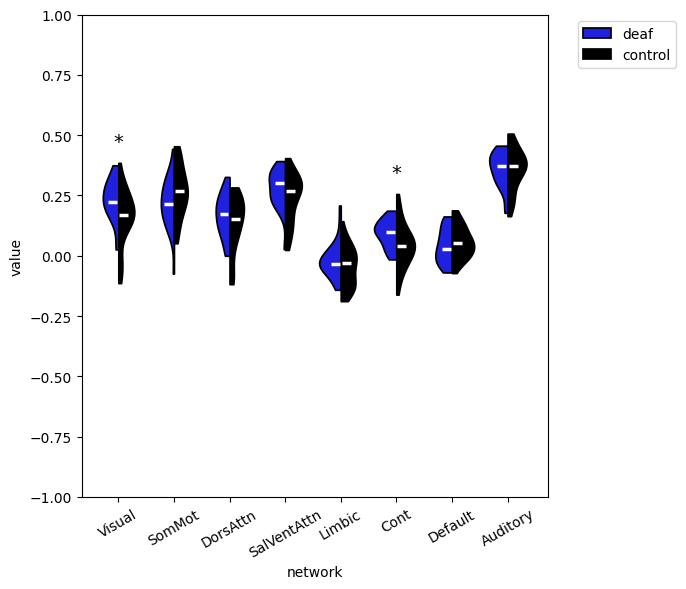

In [46]:
for region in [df_A1_network]:

    # -------------------------
    # Long format
    # -------------------------
    df_long = region.melt(
        id_vars=['group'],
        var_name='network',
        value_name='value'
    )

    df_long['group'] = pd.Categorical(
        df_long['group'],
        categories=['deaf', 'control'],
        ordered=True
    )

    network_order = df_long['network'].unique()

    plt.figure(figsize=(7, 6))

    ax = sns.violinplot(
        x='network',
        y='value',
        hue='group',
        data=df_long,
        order=network_order,
        split=True,
        inner=None,
        cut=0,
        palette={'deaf': 'blue', 'control': 'black'}
    )

    # -------------------------
    # Median lines
    # -------------------------
    medians = (
        df_long.groupby(['network', 'group'])['value']
        .median()
        .reset_index()
    )

    offset = 0.18

    for i, net in enumerate(network_order):
        for group, sign in zip(['deaf', 'control'], [-1, 1]):

            val = medians.loc[
                (medians['network'] == net) &
                (medians['group'] == group),
                'value'
            ].values

            if len(val) == 0:
                continue

            ax.hlines(
                y=val[0],
                xmin=i + sign * 0.02,
                xmax=i + sign * offset,
                color='white',
                linewidth=2.5,
                zorder=10
            )

    # -------------------------
    # Statistics + FDR
    # -------------------------
    p_vals = []

    for i, net in enumerate(network_order):

        deaf = df_long[(df_long['group'] == 'deaf') & (df_long['network'] == net)]['value']
        control = df_long[(df_long['group'] == 'control') & (df_long['network'] == net)]['value']

        t, p = ttest_ind(deaf, control, nan_policy='omit')
        print(net, t, p)
        p_vals.append(p)

        if p < 0.001:
            star = '***'
        elif p < 0.01:
            star = '**'
        elif p < 0.05:
            star = '*'
        else:
            star = ''

        y_max = df_long[df_long['network'] == net]['value'].max()

        ax.text(
            i,
            y_max + 0.05,
            star,
            ha='center',
            va='bottom',
            fontsize=14
        )

    _, p_fdr, _, _ = multipletests(p_vals, method='fdr_bh')
    print("FDR-adjusted p-values:", p_fdr)

    # -------------------------
    # Final formatting
    # -------------------------
    ax.set_ylim(-1, 1)
    ax.set_xticklabels(network_order, rotation=30)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()